<a href="https://colab.research.google.com/github/Jahnavi-711/DL-Lab-Work/blob/main/DL_EXP_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense


In [2]:
(X_train, _), (X_test, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [4]:
X_train = X_train.reshape((len(X_train), 784))
X_test = X_test.reshape((len(X_test), 784))

print("Training Shape:", X_train.shape)

Training Shape: (60000, 784)


In [5]:
input_dim = 784

encoding_dim = 32

# Encoder
input_layer = Input(shape=(input_dim,))

encoded = Dense(
    128,
    activation='relu'
)(input_layer)

encoded = Dense(
    64,
    activation='relu'
)(encoded)

encoded_output = Dense(
    encoding_dim,
    activation='relu'
)(encoded)

# Decoder
decoded = Dense(
    64,
    activation='relu'
)(encoded_output)

decoded = Dense(
    128,
    activation='relu'
)(decoded)

decoded_output = Dense(
    input_dim,
    activation='sigmoid'
)(decoded)

# Auto-Encoder
autoencoder = Model(
    input_layer,
    decoded_output
)

# Encoder Model for Dimensionality Reduction
encoder = Model(
    input_layer,
    encoded_output
)


autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.2470 - val_loss: 0.1652
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1473 - val_loss: 0.1317
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1266 - val_loss: 0.1204
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1184 - val_loss: 0.1139
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1131 - val_loss: 0.1095
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1093 - val_loss: 0.1061
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1058 - val_loss: 0.1033
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1033 - val_loss: 0.1011
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1014 - val_loss: 0.0993
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0997 - val_loss: 0.0983
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0981 - val_loss: 0.0970
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
reduced_features = encoder.predict(X_test)

print("\nReduced Feature Shape:")

print(reduced_features.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Reduced Feature Shape:
(10000, 32)


In [8]:
decoded_imgs = autoencoder.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


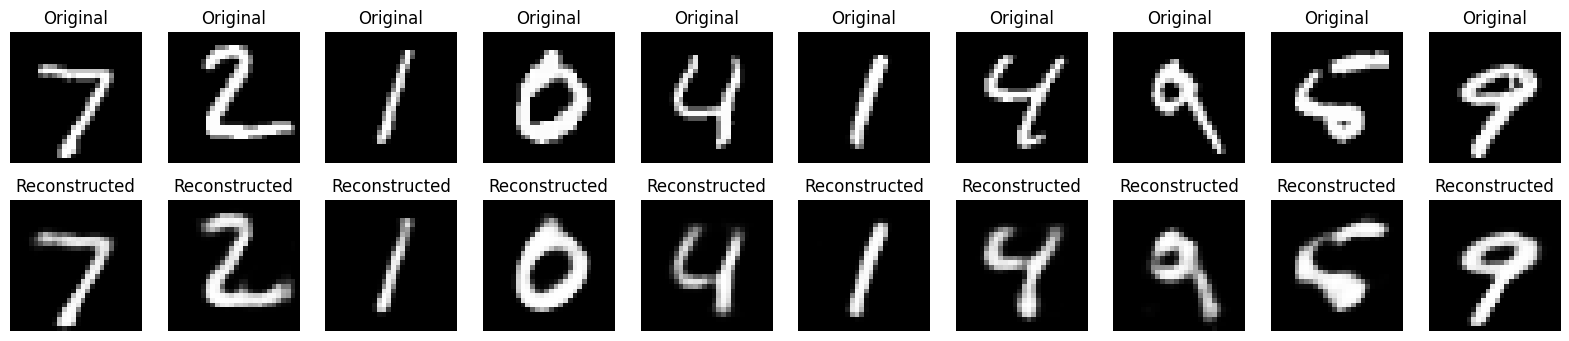

In [9]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original Images
    ax = plt.subplot(2, n, i + 1)

    plt.imshow(
        X_test[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Original")

    plt.axis('off')

    # Reconstructed Images
    ax = plt.subplot(2, n, i + 1 + n)

    plt.imshow(
        decoded_imgs[i].reshape(28,28),
        cmap='gray'
    )

    plt.title("Reconstructed")

    plt.axis('off')

plt.show()

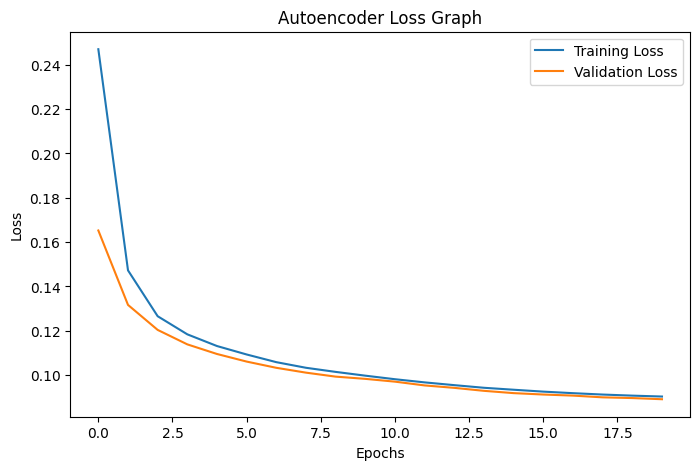

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Autoencoder Loss Graph")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.show()